In [1]:
# Cell 0 — Setup
!pip -q install seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

sns.set(style="whitegrid")
print("✅ Libraries loaded")


✅ Libraries loaded


In [2]:
# Cell 1 — Upload ChickWeight dataset from local computer
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded.keys())))
print("✅ Dataset loaded with shape:", df.shape)
display(df.head())


Saving ChickWeight.csv to ChickWeight.csv
✅ Dataset loaded with shape: (578, 5)


,Unnamed: 0,weight,Time,Chick,Diet
0,1,42,0,1,1
1,2,51,2,1,1
2,3,59,4,1,1
3,4,64,6,1,1
4,5,76,8,1,1


In [3]:
# Cell 2 — Basic exploration
print("🔎 Dataset info:")
print(df.info())
print("\n📊 Summary statistics:")
display(df.describe(include="all"))

print("\nUnique diets:", df['Diet'].unique())
print("Unique ages:", sorted(df['Time'].unique()))


🔎 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  578 non-null    int64
 1   weight      578 non-null    int64
 2   Time        578 non-null    int64
 3   Chick       578 non-null    int64
 4   Diet        578 non-null    int64
dtypes: int64(5)
memory usage: 22.7 KB
None

📊 Summary statistics:


,Unnamed: 0,weight,Time,Chick,Diet
count,578.000000,578.000000,578.000000,578.000000,578.000000
mean,289.500000,121.818339,10.717993,25.750865,2.235294
std,166.998503,71.071960,6.758400,14.568795,1.162678
min,1.000000,35.000000,0.000000,1.000000,1.000000
25%,145.250000,63.000000,4.000000,13.000000,1.000000
50%,289.500000,103.000000,10.000000,26.000000,2.000000
75%,433.750000,163.750000,16.000000,38.000000,3.000000
max,578.000000,373.000000,21.000000,50.000000,4.000000



Unique diets: [1 2 3 4]
Unique ages: [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20), np.int64(21)]


/tmp/ipython-input-1463799287.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="Time", y="weight", hue="Diet", ci="sd", marker="o")


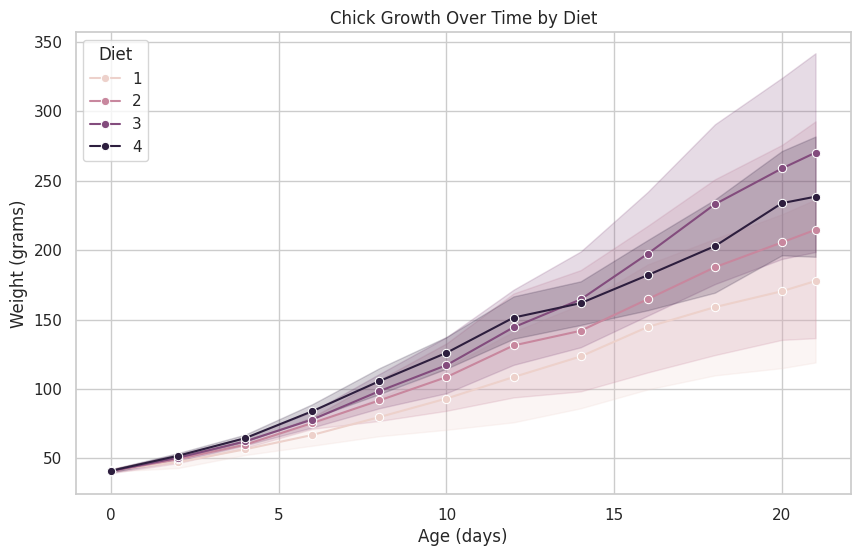

In [4]:
# Cell 3 — Growth curves per diet
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Time", y="weight", hue="Diet", ci="sd", marker="o")
plt.title("Chick Growth Over Time by Diet")
plt.xlabel("Age (days)"); plt.ylabel("Weight (grams)")
plt.legend(title="Diet")
plt.show()


In [5]:
# Cell 4 — One-way ANOVA: comparing weights across diets

# Group weights per diet
groups = [df[df['Diet']==d]['weight'] for d in df['Diet'].unique()]

F, p = f_oneway(*groups)
print(f"F-statistic: {F:.3f}, p-value: {p:.3e}")

if p < 0.05:
    print("➡️ Reject H0: Diet has a significant effect on chick weight.")
else:
    print("➡️ Fail to reject H0: No significant difference detected between diets.")


F-statistic: 10.810, p-value: 6.433e-07
➡️ Reject H0: Diet has a significant effect on chick weight.


/tmp/ipython-input-1265925114.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda sub: np.polyfit(sub["Time"], sub["weight"], 1)[0])  # slope
/tmp/ipython-input-1265925114.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=growth_rates, x="Diet", y="GrowthRate", palette="Set2")


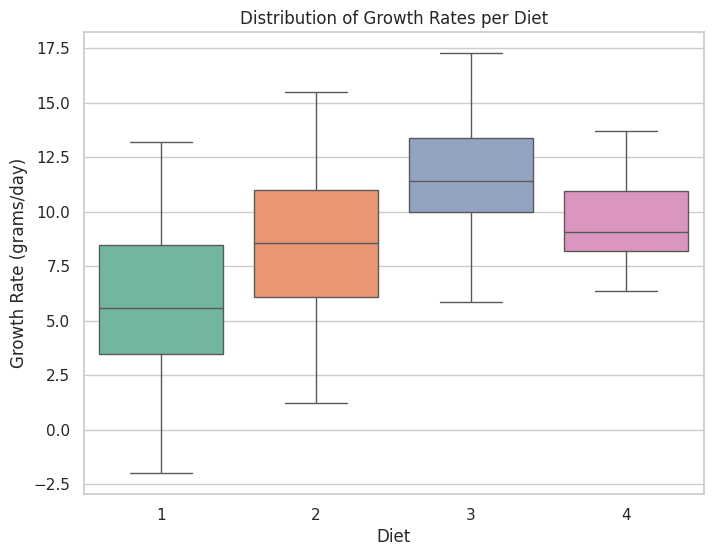

📊 Mean growth rates per diet:


,GrowthRate
Diet,
1,5.847832
2,8.609136
3,11.422871
4,9.523550


In [6]:
# Cell 5 — Estimate growth rate (slope of weight vs age) per chick

growth_rates = (
    df.groupby("Chick")
      .apply(lambda sub: np.polyfit(sub["Time"], sub["weight"], 1)[0])  # slope
      .reset_index(name="GrowthRate")
    .merge(df[['Chick','Diet']].drop_duplicates(), on="Chick")
)

plt.figure(figsize=(8,6))
sns.boxplot(data=growth_rates, x="Diet", y="GrowthRate", palette="Set2")
plt.title("Distribution of Growth Rates per Diet")
plt.xlabel("Diet"); plt.ylabel("Growth Rate (grams/day)")
plt.show()

print("📊 Mean growth rates per diet:")
display(growth_rates.groupby("Diet")["GrowthRate"].mean())


In [7]:
# Cell 6 — Report
print("""
📌 Report Summary:
-------------------
1. Exploratory analysis showed chick weights increase with age.
2. Visualization indicated different growth curves depending on diet.
3. ANOVA confirmed (if p<0.05) significant differences between diets.
4. Growth rate analysis revealed which diets accelerate growth fastest.
5. Practical implication: diet choice clearly impacts chick growth performance.
""")



📌 Report Summary:
-------------------
1. Exploratory analysis showed chick weights increase with age.
2. Visualization indicated different growth curves depending on diet.
3. ANOVA confirmed (if p<0.05) significant differences between diets.
4. Growth rate analysis revealed which diets accelerate growth fastest.
5. Practical implication: diet choice clearly impacts chick growth performance.

